Mann-Kendall Test for NEE
Reference: https://github.com/mombadi/Ombadi-Risser-2022-_Increasing-Trends-in-Extreme-Volatility-of-Daily-Max-Temperature/blob/main/GHCN.ipynb

In [1]:

import os
import glob 
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from datetime import datetime
import cartopy
import cartopy.crs as crs
import cartopy.feature as cfeature
import pymannkendall as mk
import scipy as sc
import cartopy
import cartopy.crs as crs
import cartopy.feature as cfeature
import math
import seaborn as sns
%matplotlib inline
pd.options.mode.chained_assignment = None  # default='warn

In [2]:
import constants

In [27]:
nee_msa_mean = pd.read_csv(constants.NEE_MSA_MONTHLY_MEAN)
msa_region_name = pd.read_csv(constants.MSA_NAME_REGION_TABLE)

In [ ]:
# Filter data for a given MSA
msa_data = nee_msa_mean[nee_msa_mean['NAMELSAD'] == "Toledo, OH Metro Area"].iloc[:, 1:].values.flatten()

# Run the Mann-Kendall test
msa_data = mk.original_test(msa_data)
print(msa_data)


Mann_Kendall_Test(trend='no trend', h=np.False_, p=np.float64(1.0), z=0, Tau=np.float64(0.0), s=np.float64(0.0), var_s=653350.0, slope=np.float64(6.66185238171367e-07), intercept=np.float64(0.25760645335381827))


In [28]:
# Loop through each row in nee_msa_mean
for index, row in nee_msa_mean.iterrows():
    # Extract the MSA data for the current row
    msa_data = row.iloc[1:].values.flatten()
    
    # Perform the Mann-Kendall test
    result = mk.original_test(msa_data, alpha=0.05)
    
    # Save the results as new columns
    nee_msa_mean.loc[index, 'p'] = result.p
    nee_msa_mean.loc[index, 'slope'] = result.slope
    nee_msa_mean.loc[index, 'trend'] = result.trend

In [31]:
nee_trend = nee_msa_mean[['NAMELSAD', 'p', 'slope', 'trend']]

In [32]:
trend_counts = nee_trend['trend'].value_counts()
print(trend_counts)

trend
no trend      364
increasing     19
Name: count, dtype: int64


In [35]:
increasing_msa = nee_trend[nee_trend['trend'] == 'increasing']
increasing_msa

,NAMELSAD,p,slope,trend
1,"Wichita Falls, TX Metro Area",0.046525,0.000750,increasing
20,"San Luis Obispo-Paso Robles, CA Metro Area",0.002856,0.001452,increasing
31,"El Centro, CA Metro Area",0.005437,0.001098,increasing
45,"Salinas, CA Metro Area",0.008258,0.001434,increasing
67,"Santa Maria-Santa Barbara, CA Metro Area",0.000007,0.002708,increasing
93,"San Angelo, TX Metro Area",0.002310,0.000691,increasing
94,"Sierra Vista-Douglas, AZ Metro Area",0.008946,0.000372,increasing
105,"Killeen-Temple, TX Metro Area",0.042590,0.000700,increasing
107,"Bakersfield-Delano, CA Metro Area",0.000769,0.000913,increasing
108,"Abilene, TX Metro Area",0.000323,0.000864,increasing


increasing in NEE means there are less fixed carbon in average

In [42]:
ppt = pd.read_csv(constants.PPT_MEAN_FILE).rename(columns={'Unnamed: 0': 'NAMELSAD'})

In [46]:
len(ppt.columns)

181

In [77]:
def mk_trend_test(df, alpha=0.05, name='NAMELSAD'):
    """
    Perform the Mann-Kendall trend test on each row of the DataFrame.
    
    Parameters:
        df (pd.DataFrame): DataFrame with time series data.
            assuming the first column is the index (e.g., NAMELSAD). the rest are time series values.
        name (str): Name of the first column in the DataFrame ('NAMELSAD' in this case).
        alpha (float): Significance level for the test.
        
    Returns:
        pd.DataFrame: DataFrame with trend test results.
    """
    results = []
    for index, row in df.iterrows():
        msa_data = row.iloc[1:].values.flatten()

        # Perform the Mann-Kendall test
        result = mk.original_test(msa_data, alpha=0.05)
        results.append([row[name], result.p, result.slope, result.trend])
    
    return pd.DataFrame(results, columns=[name, 'p', 'slope', 'trend'], index=df.index)

ppt_df = pd.read_csv(constants.PPT_MEAN_FILE).rename(columns={'Unnamed: 0': 'NAMELSAD'})
tmean_df = pd.read_csv(constants.TMEAN_MEAN_FILE).rename(columns={'Unnamed: 0': 'NAMELSAD'})
tdmean_df = pd.read_csv(constants.TDMEAN_MEAN_FILE).rename(columns={'Unnamed: 0': 'NAMELSAD'})
ppt_trend = mk_trend_test(ppt_df)
tdmean_trend = mk_trend_test(tdmean_df)
tmean_trend = mk_trend_test(tmean_df)

In [79]:
for c_i, trend_df in {'ppt':ppt_trend, 'tmean':tmean_trend, 'tdmean':tdmean_trend}.items():
    increasing = trend_df[trend_df['trend'] == 'increasing']
    decreasing = trend_df[trend_df['trend'] == 'decreasing']
    
    if increasing.empty:
        print(f'No increasing MSAs found for {c_i}.')
    else:
        print(f"Number of increasing {c_i} MSAs: {len(increasing)}")
        print('increasing MSAs:', increasing['NAMELSAD'].values)

    if decreasing.empty:
        print(f'No decreasing MSAs found for {c_i}.')
    else:
        print(f"Number of decreasing {c_i} MSAs: {len(decreasing)}")
        print('decreasing MSAs:', decreasing['NAMELSAD'].values)    

Number of increasing ppt MSAs: 4
increasing MSAs: ['Bismarck, ND Metro Area' 'Minot, ND Metro Area' 'Bangor, ME Metro Area'
 'Lewiston-Auburn, ME Metro Area']
No decreasing MSAs found for ppt.
No increasing MSAs found for tmean.
No decreasing MSAs found for tmean.
No increasing MSAs found for tdmean.
Number of decreasing tdmean MSAs: 7
decreasing MSAs: ['San Luis Obispo-Paso Robles, CA Metro Area' 'El Centro, CA Metro Area'
 'Salinas, CA Metro Area' 'Yuma, AZ Metro Area'
 'Hanford-Corcoran, CA Metro Area'
 'Riverside-San Bernardino-Ontario, CA Metro Area'
 'Santa Cruz-Watsonville, CA Metro Area']


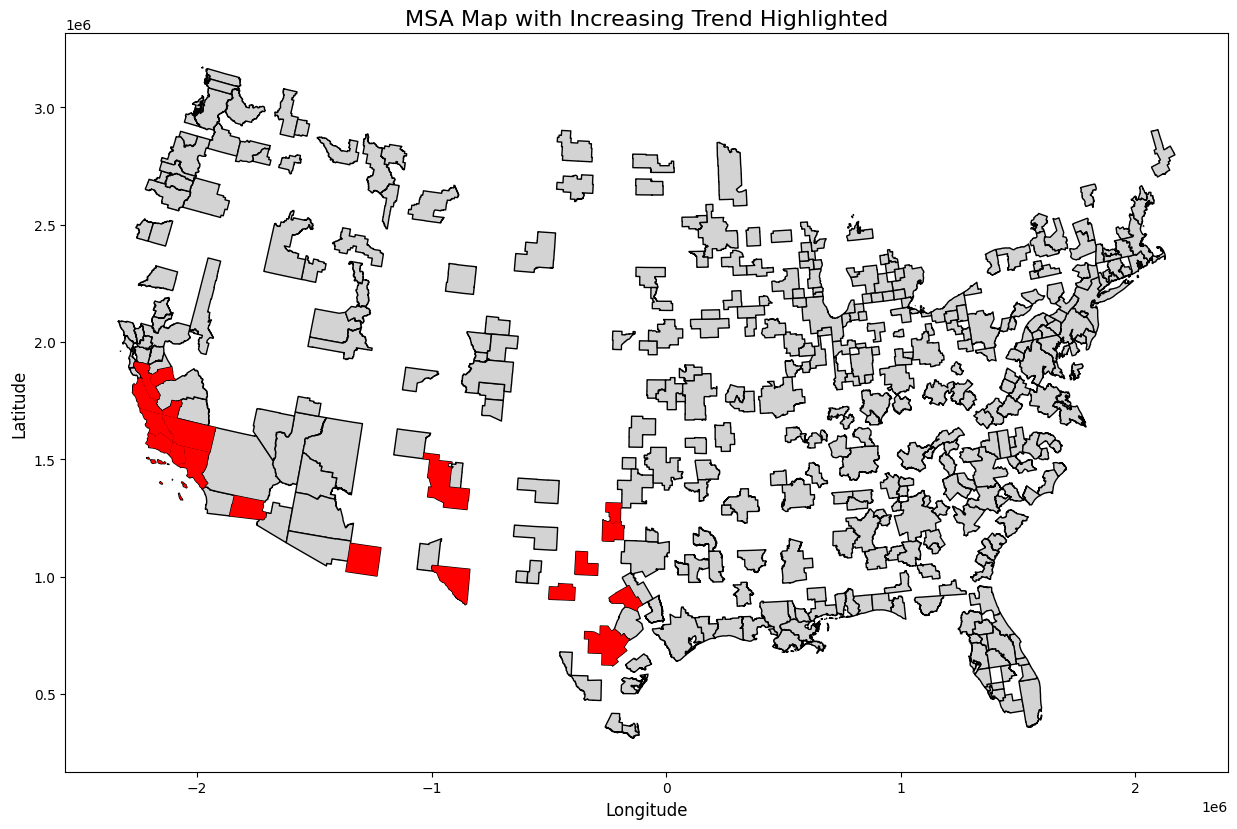

In [ ]:
import geopandas as gpd

# MSA_FILE = r'c:\Users\qifanw\Documents\gis\msa\msaUS_mland_aea1_M1_all.shp'
# Load the shapefile
msa_shp = gpd.read_file(constants.MSA_FILE)

# Plot the shapefile on a map
fig, ax = plt.subplots(figsize=(15, 10))
msa_shp.plot(ax=ax, color='lightgrey', edgecolor='black')

# Highlight the MSAs with increasing trend in red
highlighted = msa_shp[msa_shp['NAMELSAD'].isin(increasing_msa['NAMELSAD'])]
highlighted.plot(ax=ax, color='red')

# Add title and labels
ax.set_title('MSA Map with Increasing Trend Highlighted', fontsize=16)
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)

plt.show()

